# Automatic Differentiation for Physics

This notebook is the first stop in the `01_foundations_extensions` research track.

It goes deeper than the tiny autodiff bridge used in the core path. The goal is to make the *derivative machinery* that physics-informed learning relies on feel concrete, so that the residual operators used by PINNs, the Jacobians/Hessians used in inverse problems, and the gradient flows used in operator learning are no longer black boxes.

We stay on a small canonical problem and compare three ways of computing the same derivatives:

1. numerical finite differences,
2. symbolic differentiation with SymPy (treated as ground truth),
3. automatic differentiation with PyTorch in both reverse and forward flavour.

We finish by reproducing two findings that matter for scientific ML: AD matches symbolic derivatives to machine precision, and reverse mode wins decisively when the output is a scalar loss over many inputs.

## Notebook Contract

- **Status:** research-executable
- **Lane:** `10_Research_Tracks/01_foundations_extensions`
- **Research question:** How do finite differences, symbolic differentiation, and automatic differentiation compare when we need high-order derivatives, Jacobians, Hessians, and PINN residual operators?
- **Canonical problem:** scalar field $u(x) = \sin(\pi x)\,e^{-x^2}$ on $[-1, 1]$, plus a small vector field $\mathbf{F}: \mathbb{R}^2 \to \mathbb{R}^2$ and scalar potential $\Phi: \mathbb{R}^2 \to \mathbb{R}$.
- **Prerequisites:** multivariable calculus, basic PyTorch tensors, the autodiff bridge in `01_Core_Path/01_pde_primer_and_numerical_methods.ipynb`.
- **Deliverable:** a side-by-side accuracy and cost comparison of FD, SymPy, and autograd for first-to-fourth order derivatives, plus a working PINN-style residual operator over a batch of collocation points.
- **Estimated runtime:** under 1 minute on CPU.
- **References:**
  - Baydin, Pearlmutter, Radul, Siskind. *Automatic Differentiation in Machine Learning: a Survey* (JMLR, 2018).
  - Raissi, Perdikaris, Karniadakis. *Physics-Informed Neural Networks* (JCP, 2019).
  - Paszke et al. *Automatic Differentiation in PyTorch* (NeurIPS WS, 2017).
- **Next notebooks:** [02_spectral_methods_and_fourier_analysis.ipynb](02_spectral_methods_and_fourier_analysis.ipynb), [03_neural_network_function_approximation.ipynb](03_neural_network_function_approximation.ipynb).

## Why This Notebook Exists

PINNs and neural operators are sold as "PDEs with a neural ansatz", but their training loop is driven entirely by derivative operators. If those operators are wrong, slow, or numerically noisy, every downstream method inherits the problem.

A clean way to demystify them is to ask three things at once:

- can we compute the same derivatives with a classical method, a symbolic system, and an autograd engine?
- where does each method break (step size, expression swell, graph construction)?
- what does a reusable PINN residual operator look like when we strip away the optimizer and the network?

This notebook keeps the comparison tight: one smooth scalar field, one vector field, one potential, one collocation loop.

## Two Modes of Differentiation

Before comparing numbers it helps to fix the vocabulary that the rest of the repo will use.

**Forward mode** propagates derivatives from inputs to outputs alongside the primal computation. For $f: \mathbb{R}^n \to \mathbb{R}^m$, one forward sweep computes one column of the Jacobian $\partial f / \partial x_j$ for a chosen $j$. Cost is $O(\text{cost}(f))$ per column.

**Reverse mode** propagates an output seed back to all inputs. For a scalar output $f: \mathbb{R}^n \to \mathbb{R}$, one reverse sweep computes the entire gradient $\nabla f \in \mathbb{R}^n$. Cost is $O(\text{cost}(f))$ for the whole gradient, with memory proportional to the size of the computation graph.

**Rule of thumb in scientific ML:**

| Setting | Usual winner | Reason |
|---|---|---|
| PINN scalar residual summed over collocation points | reverse mode | one scalar, many inputs |
| Per-coordinate sensitivity of a vector output | forward mode or vectorized Jacobian | instead of $m$ reverse sweeps |
| High-order PDE residual $u_{xx}, u_{xxx}$ | reverse mode with `create_graph=True` | each order reuses the previous graph |
| Systems with millions of parameters and a scalar loss | reverse mode | the entire deep-learning default |

PyTorch is reverse-mode by default. We will use `create_graph=True` to keep the graph alive and differentiate through it again, which is the same primitive that PINN residuals require.

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import torch

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(7)
torch.manual_seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())

print(f"Repo root: {repo_root}")
print(f"NumPy:   {np.__version__}")
print(f"SymPy:   {sp.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"Device:  {device}")

Repo root: /home/duncan-nguyen/research/physics-informed-learning
NumPy:   2.4.3
SymPy:   1.14.0
PyTorch: 2.10.0+cu128
Device:  cpu


## Canonical Scalar Field

We work on the interval $[-1, 1]$ with the smooth field

$$ u(x) = \sin(\pi x)\, e^{-x^2}. $$

It is smooth, oscillatory, and non-trivial, which is enough to expose the failure modes of finite differences while remaining cheap for symbolic differentiation up to order four.

SymPy gives us the exact derivatives that every other method will be measured against.

In [2]:
x_sym = sp.symbols("x", real=True)
u_sym = sp.sin(sp.pi * x_sym) * sp.exp(-(x_sym ** 2))

u_derivs_sym = [sp.diff(u_sym, x_sym, k) for k in range(5)]
u_derivs_lambda = [sp.lambdify(x_sym, expr, "numpy") for expr in u_derivs_sym]

print("u  =", u_sym)
for k in range(1, 5):
    print(f"u_{'x' * k} =", sp.simplify(u_derivs_sym[k]))

u  = exp(-x**2)*sin(pi*x)
u_x = (-2*x*sin(pi*x) + pi*cos(pi*x))*exp(-x**2)
u_xx = (-4*pi*x*cos(pi*x) + (4*x**2 - 2)*sin(pi*x) - pi**2*sin(pi*x))*exp(-x**2)
u_xxx = (-4*x*(2*x**2 - 3)*sin(pi*x) + 6*pi**2*x*sin(pi*x) + 6*pi*(2*x**2 - 1)*cos(pi*x) - pi**3*cos(pi*x))*exp(-x**2)
u_xxxx = (-16*pi*x*(2*x**2 - 3)*cos(pi*x) + 8*pi**3*x*cos(pi*x) - 12*pi**2*(2*x**2 - 1)*sin(pi*x) + (16*x**4 - 48*x**2 + 12)*sin(pi*x) + pi**4*sin(pi*x))*exp(-x**2)


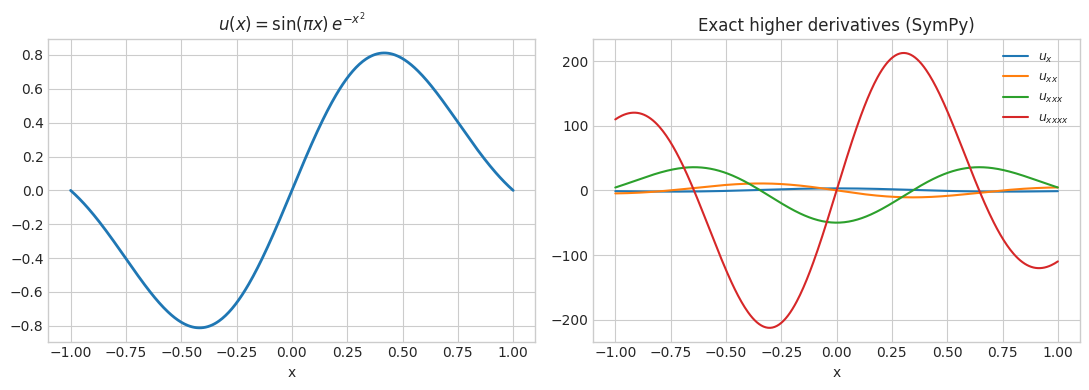

In [3]:
grid = np.linspace(-1.0, 1.0, 401)
u_exact = u_derivs_lambda[0](grid)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(grid, u_exact, color="tab:blue", linewidth=2)
axes[0].set_title(r"$u(x) = \sin(\pi x)\,e^{-x^2}$")
axes[0].set_xlabel("x")

for k in range(1, 5):
    axes[1].plot(grid, u_derivs_lambda[k](grid), label=f"$u_{'{'+'x'*k+'}'}$")
axes[1].set_title("Exact higher derivatives (SymPy)")
axes[1].set_xlabel("x")
axes[1].legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

## Method 1: Finite Differences

Central differences use the symmetric stencil

$$ u'(x) \approx \frac{u(x+h) - u(x-h)}{2h}, \qquad u''(x) \approx \frac{u(x+h) - 2u(x) + u(x-h)}{h^2}. $$

The truncation error is $O(h^2)$, but rounding error grows like $O(\varepsilon / h)$. There is therefore an optimal step size $h^* \sim \varepsilon^{1/3}$ for the first derivative and $h^* \sim \varepsilon^{1/4}$ for the second. We see this clearly in the error curves below.

SymPy u'(0.37)   = 0.495798197859
Best FD1 step h  = 1.468e-07, error = 5.763e-12
Best FD2 step h  = 7.017e-05, error = 5.552e-08


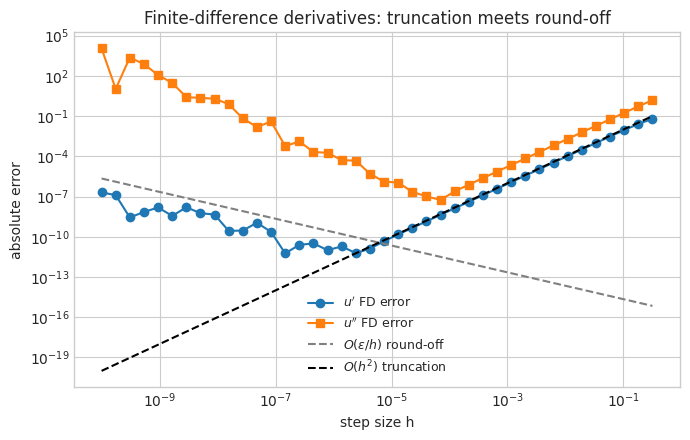

In [4]:
u_np = u_derivs_lambda[0]

def fd_first_derivative(f, x, h):
    return (f(x + h) - f(x - h)) / (2.0 * h)

def fd_second_derivative(f, x, h):
    return (f(x + h) - 2.0 * f(x) + f(x - h)) / (h ** 2)

hs = np.logspace(-10, -0.5, 40)
x_eval = 0.37
fd1_err = [abs(fd_first_derivative(u_np, x_eval, h) - u_derivs_lambda[1](x_eval)) for h in hs]
fd2_err = [abs(fd_second_derivative(u_np, x_eval, h) - u_derivs_lambda[2](x_eval)) for h in hs]

print(f"SymPy u'(0.37)   = {float(u_derivs_lambda[1](x_eval)):.12f}")
print(f"Best FD1 step h  = {hs[int(np.argmin(fd1_err))]:.3e}, error = {min(fd1_err):.3e}")
print(f"Best FD2 step h  = {hs[int(np.argmin(fd2_err))]:.3e}, error = {min(fd2_err):.3e}")

plt.figure(figsize=(7, 4.5))
plt.loglog(hs, fd1_err, "o-", label=r"$u'$ FD error")
plt.loglog(hs, fd2_err, "s-", label=r"$u''$ FD error")
eps = np.finfo(float).eps
plt.loglog(hs, eps / hs, "--", color="gray", label=r"$O(\varepsilon/h)$ round-off")
plt.loglog(hs, hs ** 2, "--", color="black", label=r"$O(h^2)$ truncation")
plt.xlabel("step size h")
plt.ylabel("absolute error")
plt.title("Finite-difference derivatives: truncation meets round-off")
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

## Method 2: Reverse-Mode Autograd, First Derivative

Because $u$ is a scalar function of a scalar input, reverse mode gives us $u'(x)$ in a single sweep. The only subtlety is that the input $x$ must carry `requires_grad=True` so autograd has a leaf to flow derivatives into.

In [5]:
def u_torch(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(torch.pi * x) * torch.exp(-(x ** 2))

x_q = torch.tensor([x_eval], dtype=torch.float64, requires_grad=True)
u_q = u_torch(x_q)
u_q.backward()
ad_first = float(x_q.grad)

sym_first = float(u_derivs_lambda[1](x_eval))
print(f"SymPy    u' = {sym_first:.15f}")
print(f"autograd u' = {ad_first:.15f}")
print(f"|error|     = {abs(ad_first - sym_first):.3e}")

SymPy    u' = 0.495798197859369
autograd u' = 0.495798197859369
|error|     = 0.000e+00


## Method 3: Higher-Order Autograd via `create_graph=True`

To differentiate an already-differentiated expression we ask PyTorch to materialise the derivative graph by passing `create_graph=True`. Each call to `autograd.grad` then produces a differentiable tensor, so the next order can flow through it.

This is exactly the primitive a PINN residual uses: $u_{xx}$ on a batch of collocation points is `grad(grad(u, x)[0], x)[0]` with the graph kept alive.

In [6]:
def ad_derivative(u_fn, x: torch.Tensor, order: int) -> torch.Tensor:
    x = x.detach().clone().requires_grad_(True)
    y = u_fn(x)
    grad_p = y
    for _ in range(order):
        grad_p = torch.autograd.grad(
            grad_p,
            x,
            grad_outputs=torch.ones_like(grad_p),
            create_graph=True,
            retain_graph=True,
        )[0]
    return grad_p.detach()

eval_tensor = torch.tensor([x_eval], dtype=torch.float64)
print(f"{'order':<6}{'SymPy':<22}{'autograd':<22}{'|error|':<12}")
for k in range(1, 5):
    sym_val = float(u_derivs_lambda[k](x_eval))
    ad_val = float(ad_derivative(u_torch, eval_tensor, k))
    print(f"{k:<6}{sym_val:<22.15f}{ad_val:<22.15f}{abs(sym_val - ad_val):<12.3e}")

order SymPy                 autograd              |error|     


1     0.495798197859369     0.495798197859369     0.000e+00   
2     -10.671701363419501   -10.671701363419501   0.000e+00   
3     5.285506837539284     5.285506837539283     8.882e-16   
4     200.725954689724688   200.725954689724688   0.000e+00   


## Jacobian of a Vector Field

Now consider a map $\mathbf{F}: \mathbb{R}^2 \to \mathbb{R}^2$ representing, for example, a steady 2D velocity field written as a function of position:

$$ \mathbf{F}(x, y) = \big( \sin(\pi x)\cos(\pi y),\; -\cos(\pi x)\sin(\pi y) \big). $$

Its Jacobian is a $2 \times 2$ matrix. Reverse mode computes it row by row (one reverse sweep per output coordinate), forward mode computes it column by column (one forward sweep per input). We keep the reverse-mode recipe here because it is what the rest of the repo will need.

In [7]:
def F_torch(xy: torch.Tensor) -> torch.Tensor:
    x = xy[..., 0]
    y = xy[..., 1]
    f1 = torch.sin(torch.pi * x) * torch.cos(torch.pi * y)
    f2 = -(torch.cos(torch.pi * x) * torch.sin(torch.pi * y))
    return torch.stack([f1, f2], dim=-1)

def jacobian_reverse(fun, x: torch.Tensor) -> torch.Tensor:
    x = x.detach().clone().requires_grad_(True)
    y = fun(x)
    rows = []
    for i in range(y.shape[-1]):
        g = torch.autograd.grad(
            y[..., i],
            x,
            grad_outputs=torch.ones_like(y[..., i]),
            create_graph=False,
            retain_graph=True,
        )[0]
        rows.append(g)
    return torch.stack(rows, dim=-2).detach()

x_y, y_y = sp.symbols("x y", real=True)
F_sym = sp.Matrix([sp.sin(sp.pi * x_y) * sp.cos(sp.pi * y_y), -sp.cos(sp.pi * x_y) * sp.sin(sp.pi * y_y)])
J_sym = F_sym.jacobian([x_y, y_y])
J_lambda = sp.lambdify((x_y, y_y), J_sym, "numpy")

xy0 = torch.tensor([[0.31, -0.47]], dtype=torch.float64)
J_ad = jacobian_reverse(F_torch, xy0).numpy()[0]
J_sp = np.array(J_lambda(float(xy0[0, 0]), float(xy0[0, 1])), dtype=np.float64)

print("autograd Jacobian:")
print(J_ad)
print("SymPy Jacobian:")
print(J_sp)
print(f"max |diff| = {np.max(np.abs(J_ad - J_sp)):.3e}")

autograd Jacobian:
[[ 0.16617994  2.58681869]
 [-2.58681869 -0.16617994]]
SymPy Jacobian:
[[ 0.16617994  2.58681869]
 [-2.58681869 -0.16617994]]
max |diff| = 4.441e-16


## Hessian of a Scalar Potential

For a scalar potential $\Phi: \mathbb{R}^2 \to \mathbb{R}$, the gradient is a vector and the Hessian is a $2 \times 2$ matrix. We use

$$ \Phi(x, y) = \cos(\pi x)\, e^{-y^2}. $$

The Hessian is the Jacobian of the gradient, so we compose two reverse-mode sweeps. This pattern recurs in second-order optimisation, inverse-problem preconditioners, and Lagrangian/Hamiltonian neural networks in `04_structure_preserving_networks`.

In [8]:
def Phi_torch(xy: torch.Tensor) -> torch.Tensor:
    x = xy[..., 0]
    y = xy[..., 1]
    return torch.cos(torch.pi * x) * torch.exp(-(y ** 2))

def gradient_and_hessian(fun, x: torch.Tensor):
    x = x.detach().clone().requires_grad_(True)
    y = fun(x).sum()
    g = torch.autograd.grad(y, x, create_graph=True)[0]
    h_rows = []
    for i in range(x.shape[-1]):
        hi = torch.autograd.grad(
            g[..., i],
            x,
            grad_outputs=torch.ones_like(g[..., i]),
            create_graph=False,
            retain_graph=True,
        )[0]
        h_rows.append(hi)
    h = torch.stack(h_rows, dim=-2)
    return g.detach(), h.detach()

Phi_sym = sp.cos(sp.pi * x_y) * sp.exp(-(y_y ** 2))
grad_sym = [sp.diff(Phi_sym, v) for v in (x_y, y_y)]
hess_sym = sp.Matrix([[sp.diff(g, v) for v in (x_y, y_y)] for g in grad_sym])
hess_lambda = sp.lambdify((x_y, y_y), hess_sym, "numpy")
grad_lambda = [sp.lambdify((x_y, y_y), g, "numpy") for g in grad_sym]

g_ad, H_ad = gradient_and_hessian(Phi_torch, xy0)
g_sp = np.array([float(g(float(xy0[0, 0]), float(xy0[0, 1]))) for g in grad_lambda])
H_sp = np.array(hess_lambda(float(xy0[0, 0]), float(xy0[0, 1])), dtype=np.float64)

print(f"grad autograd = {g_ad.numpy()[0]}")
print(f"grad sympy    = {g_sp}")
print(f"Hess autograd =\n{H_ad.numpy()[0]}")
print(f"Hess sympy    =\n{H_sp}")
print(f"max |grad diff| = {np.max(np.abs(g_ad.numpy()[0] - g_sp)):.3e}")
print(f"max |Hess diff| = {np.max(np.abs(H_ad.numpy()[0] - H_sp)):.3e}")

grad autograd = [-2.08334907  0.42363608]
grad sympy    = [-2.08334907  0.42363608]
Hess autograd =
[[-4.4480006  -1.95834812]
 [-1.95834812 -0.50313545]]
Hess sympy    =
[[-4.4480006  -1.95834812]
 [-1.95834812 -0.50313545]]
max |grad diff| = 4.441e-16
max |Hess diff| = 4.441e-16


## PINN Residual Operator on a Batch of Collocation Points

We now turn the same primitive into the operator that a PINN actually needs: given a network $u_\theta(x)$ and a batch of collocation points, return the values $u, u_x, u_{xx}$ evaluated at all points in one shot. The vectorisation across the batch is what the core path notebook elided; here we make it explicit.

As a sanity check we use a network that is *exactly* the analytic solution. Its $u_{xx}$ should reproduce the SymPy second derivative on the batch to machine precision, which proves the operator is correct before any training.

In [9]:
class ExactSolutionNet(torch.nn.Module):
    def forward(self, x):
        return torch.sin(torch.pi * x) * torch.exp(-(x ** 2))

def pinn_operators(model, x: torch.Tensor):
    x = x.detach().clone().requires_grad_(True)
    u = model(x)
    u_x = torch.autograd.grad(
        u, x, grad_outputs=torch.ones_like(u), create_graph=True, retain_graph=True
    )[0]
    u_xx = torch.autograd.grad(
        u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True, retain_graph=True
    )[0]
    return u.detach(), u_x.detach(), u_xx.detach(), x

coll = torch.linspace(-1.0, 1.0, 9, dtype=torch.float64).unsqueeze(-1)
model = ExactSolutionNet().double()
u_v, u_x_v, u_xx_v, _ = pinn_operators(model, coll)

ref_x = coll.squeeze().numpy()
ref_u = u_derivs_lambda[0](ref_x)
ref_ux = u_derivs_lambda[1](ref_x)
ref_uxx = u_derivs_lambda[2](ref_x)

print(f"{'x':>6}{'|u-u*|':>14}{'|u_x-u_x*|':>16}{'|u_xx-u_xx*|':>16}")
for i in range(len(ref_x)):
    print(f"{ref_x[i]:>6.2f}"
          f"{abs(float(u_v[i]) - ref_u[i]):>14.2e}"
          f"{abs(float(u_x_v[i]) - ref_ux[i]):>16.2e}"
          f"{abs(float(u_xx_v[i]) - ref_uxx[i]):>16.2e}")

     x        |u-u*|      |u_x-u_x*|    |u_xx-u_xx*|
 -1.00      0.00e+00        0.00e+00        8.88e-16
 -0.75      0.00e+00        0.00e+00        6.38e-16
 -0.50      0.00e+00        0.00e+00        0.00e+00
 -0.25      0.00e+00        0.00e+00        1.78e-15
  0.00      0.00e+00        0.00e+00        0.00e+00
  0.25      0.00e+00        0.00e+00        1.78e-15
  0.50      0.00e+00        0.00e+00        0.00e+00
  0.75      0.00e+00        0.00e+00        6.38e-16
  1.00      0.00e+00        0.00e+00        8.88e-16


## Replacing the Exact Solution with a Random MLP

With the operator verified, we can point it at any differentiable function. A randomly initialised MLP gives us a concrete, non-trivial landscape to look at:

- $u(x)$, the function the network currently represents,
- $u_x(x)$, the operator that a first-order residual would constrain,
- $u_{xx}(x)$, the operator that governs PINN Poisson residuals,
all produced by the same `pinn_operators` routine with no manual derivation.

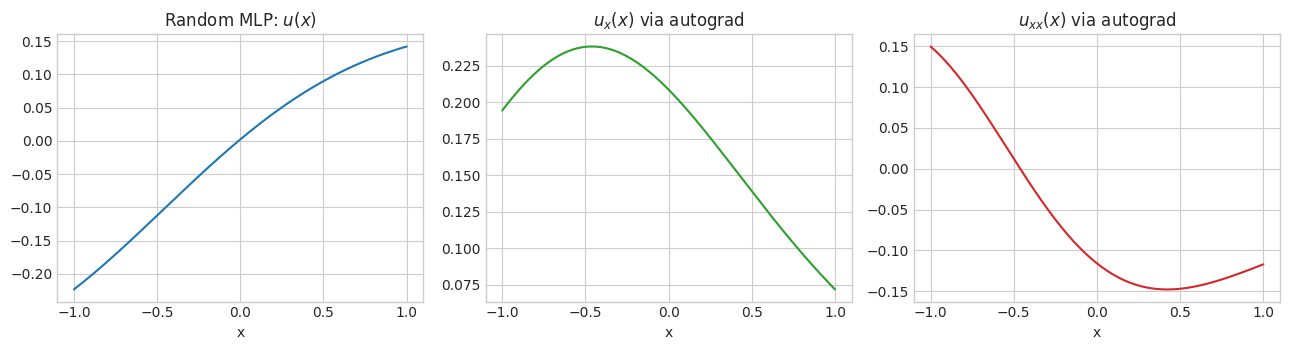

In [10]:
class MLP(torch.nn.Module):
    def __init__(self, width=32):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(1, width),
            torch.nn.Tanh(),
            torch.nn.Linear(width, width),
            torch.nn.Tanh(),
            torch.nn.Linear(width, 1),
        )

    def forward(self, x):
        return self.net(x)

torch.manual_seed(0)
mlp = MLP(width=32).double()
x_plot = torch.linspace(-1.0, 1.0, 201, dtype=torch.float64).unsqueeze(-1)
u_v, u_x_v, u_xx_v, _ = pinn_operators(mlp, x_plot)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
xs = x_plot.squeeze().numpy()
axes[0].plot(xs, u_v.numpy(), color="tab:blue")
axes[0].set_title(r"Random MLP: $u(x)$")
axes[1].plot(xs, u_x_v.numpy(), color="tab:green")
axes[1].set_title(r"$u_x(x)$ via autograd")
axes[2].plot(xs, u_xx_v.numpy(), color="tab:red")
axes[2].set_title(r"$u_{xx}(x)$ via autograd")
for ax in axes:
    ax.set_xlabel("x")
plt.tight_layout()
plt.show()

## Accuracy Side-by-Side at a Point

Finally, we focus on $u_{xx}(x)$ at $x = 0.37$, comparing a carefully tuned finite-difference stencil, reverse-mode autograd, and the symbolic reference. The point is to see that FD bottoms out near $\varepsilon^{2/3}$ while autograd sits at $\varepsilon$.

In [11]:
fd2_best_h = hs[int(np.argmin(fd2_err))]
fd2_best_val = fd_second_derivative(u_np, x_eval, fd2_best_h)
ad2_val = float(ad_derivative(u_torch, eval_tensor, 2))
sym2_val = float(u_derivs_lambda[2](x_eval))

print(f"reference (SymPy)   u_xx(0.37) = {sym2_val:.15f}")
print(f"FD (best h={fd2_best_h:.2e})      u_xx(0.37) = {fd2_best_val:.15f}  |err|={abs(fd2_best_val - sym2_val):.3e}")
print(f"autograd            u_xx(0.37) = {ad2_val:.15f}  |err|={abs(ad2_val - sym2_val):.3e}")
print(f"machine epsilon (float64)      = {np.finfo(float).eps:.3e}")

reference (SymPy)   u_xx(0.37) = -10.671701363419501
FD (best h=7.02e-05)      u_xx(0.37) = -10.671701307899228  |err|=5.552e-08
autograd            u_xx(0.37) = -10.671701363419501  |err|=0.000e+00
machine epsilon (float64)      = 2.220e-16


## Cost: Reverse Mode for a Scalar Output over Many Inputs

To make the trade-off tangible, we measure the cost of computing $\sum_i u(x_i)$'s gradient with respect to *all* $n$ inputs at once, for increasing $n$. Reverse mode does this in a single sweep whose cost grows linearly with $n$. A naive forward-mode implementation would require $n$ separate sweeps and is shown only as a reference scaling.

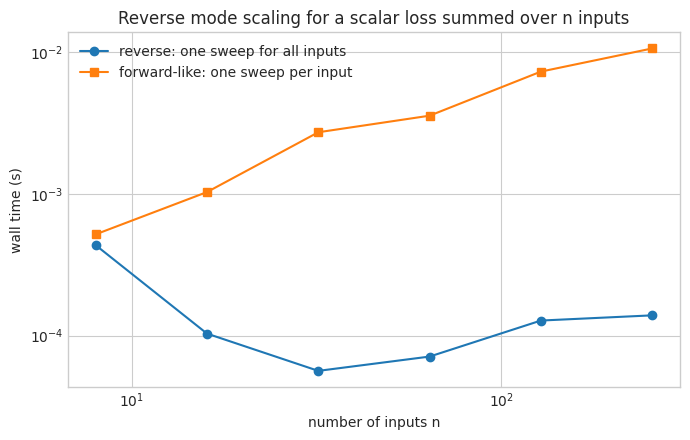

n=256 reverse vs forward wall-time ratio = 76.0x


In [12]:
def reverse_grad_sum(n):
    x = torch.linspace(-1.0, 1.0, n, dtype=torch.float64, requires_grad=True)
    y = u_torch(x).sum()
    g = torch.autograd.grad(y, x)[0]
    return g

def forward_grad_sum(n):
    x = torch.linspace(-1.0, 1.0, n, dtype=torch.float64)
    grads = torch.zeros_like(x)
    for i in range(n):
        x_i = x[i].clone().requires_grad_(True)
        y_i = u_torch(x_i)
        grads[i] = torch.autograd.grad(y_i, x_i)[0]
    return grads

ns = [8, 16, 32, 64, 128, 256]
t_rev, t_fwd = [], []
for n in ns:
    t0 = time.perf_counter()
    for _ in range(3):
        reverse_grad_sum(n)
    t_rev.append((time.perf_counter() - t0) / 3)

    t0 = time.perf_counter()
    for _ in range(3):
        forward_grad_sum(n)
    t_fwd.append((time.perf_counter() - t0) / 3)

plt.figure(figsize=(7, 4.5))
plt.loglog(ns, t_rev, "o-", label="reverse: one sweep for all inputs")
plt.loglog(ns, t_fwd, "s-", label="forward-like: one sweep per input")
plt.xlabel("number of inputs n")
plt.ylabel("wall time (s)")
plt.title("Reverse mode scaling for a scalar loss summed over n inputs")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

print(f"n=256 reverse vs forward wall-time ratio = {t_fwd[-1] / t_rev[-1]:.1f}x")

## When Each Mode Wins in Physics-Informed Learning

| Task | What we differentiate | Recommended mode | Why |
|---|---|---|---|
| PINN residual $\mathcal{R}_\theta = u_{xx} - f$ summed over collocation | scalar loss w.r.t. network params and inputs | reverse | one scalar, very many params |
| Per-collocation-point residual vector $\mathbf{R} \in \mathbb{R}^N$ | vector output | row-by-row reverse or vectorized Jacobian | needed by causal/PINN-LM methods |
| Hamiltonian $\dot q = \partial H / \partial p$ | scalar $H$ w.r.t. $(q, p)$ | reverse | gradient of a scalar |
| Inverse Hessian-vector products | scalar objective twice | reverse with `create_graph=True` | what we did above for $\Phi$ |
| Forward sensitivity of an ODE solution to one parameter | scalar param seed | forward | one column at a time |

Most of this repo will lean on reverse mode plus `create_graph=True`. That is enough to rebuild every PINN, neural-ODE, and HNN notebook from this section onward.

## Key Takeaways

- SymPy derivatives are exact and are the right ground truth for autograd verification on small problems.
- Finite differences have an irreducible $\varepsilon^{2/3}$ floor for the first derivative and $\varepsilon^{1/2}$-ish floor for the second, driven by the truncation-vs-rounding trade-off.
- Reverse-mode autograd matches the symbolic answer to machine precision for first, second, third, and fourth derivatives of a smooth field, with no step-size tuning.
- Jacobians and Hessians compose out of repeated reverse-mode sweeps with `create_graph=True`; this is the exact recipe PINN residual operators reuse.
- For a scalar loss summed over many inputs, reverse mode is asymptotically cheaper than a per-coordiante forward pass, which is why the rest of the repo can afford PINN training at all.

## References

- Baydin, Pearlmutter, Radul, Siskind. *Automatic Differentiation in Machine Learning: a Survey*. JMLR, 2018.
- Paszke et al. *Automatic Differentiation in PyTorch*. NeurIPS Autodiff Workshop, 2017.
- Raissi, Perdikaris, Karniadakis. *Physics-Informed Neural Networks: A Deep Learning Framework for Solving Forward and Inverse Problems Involving Nonlinear PDEs*. JCP, 2019.
- Griewank, Walther. *Evaluating Derivatives: Principles and Techniques of Algorithmic Differentiation*. SIAM, 2008.